In [1]:
import scanpy as sc
import squidpy as sq
import numpy as np
import matplotlib.pyplot as plt

from graph_transformer_long_range_niches.pp import sliding_window
from graph_transformer_long_range_niches._paths import CFG_FILES, RESULTS, COSMX_PANCREAS_S1, COSMX_PANCREAS

import warnings
warnings.filterwarnings('ignore')

/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)
/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load data

In [4]:
sara_spatial_pancreas = '/lustre/groups/ml01/datasets/projects/20230301_Sander_SpatialPancreas_sara.jimenez/spatial/S1_annotated_l0.h5ad'
SPATIAL_PANCREAS_FULL = '/lustre/groups/ml01/workspace/sara.jimenez/spatial_pancreas_data/preprocessed_data/data4downstream/merged_covet_niche_def_corr_per_fov.h5ad'

In [5]:
# Slide 1 
adata_s1 = sc.read_h5ad(COSMX_PANCREAS_S1)
adata_s1

AnnData object with n_obs × n_vars = 104816 × 979
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.GCG', 'Max.GCG', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'cell_ID', 'condition', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_NegPrb', 'log1p_total_counts_NegPrb', 'pct_counts_NegPrb', 'n_genes', 'cell_type_coarse', 'niche_label', 'x', 'y', 'globalX', 'globalY', 'sliding_window_1', 'sliding_window_2', 'sliding_window_3', 'sliding_window_4', 'sliding_window'
    uns: 'cell_type_coarse_colors', 'sliding_window_1_colors', 'sliding_window_2_colors', 'spatial', 'spatial_neighbors'
    obsm: 'spatial', 'spatial_fov'
    layers: 'counts'

In [4]:
subadata = adata_s1[adata_s1.obs['fov'].isin(['12', '10'])]

In [5]:
subadata

View of AnnData object with n_obs × n_vars = 9631 × 979
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.GCG', 'Max.GCG', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'cell_ID', 'condition', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_NegPrb', 'log1p_total_counts_NegPrb', 'pct_counts_NegPrb', 'n_genes', 'cell_type_coarse', 'niche_label', 'x', 'y', 'globalX', 'globalY', 'sliding_window_1', 'sliding_window_2', 'sliding_window_3', 'sliding_window_4', 'sliding_window'
    uns: 'cell_type_coarse_colors', 'sliding_window_1_colors', 'sliding_window_2_colors', 'spatial', 'spatial_neighbors'
    obsm: 'spatial', 'spatial_fov'
    layers: 'counts'

In [8]:
subadata.write('/lustre/groups/ml01/projects/2024_spatial_long_range_GT_francesca.drummer/data/cosmx_pancreas_s1_12_10.h5ad')

In [4]:
# cells_per_fov = adata.obs.groupby('fov').size()
# print(f'Cells per FOV stats: Max: {cells_per_fov.max()}, MIN: {cells_per_fov.min()}, mean: {cells_per_fov.mean()}, nr. of FOVs: {len(cells_per_fov)}')

In [6]:
# Complete data
adata = sc.read_h5ad(COSMX_PANCREAS)
adata

AnnData object with n_obs × n_vars = 386727 × 979
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.GCG', 'Max.GCG', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'cell_ID', 'condition', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_NegPrb', 'log1p_total_counts_NegPrb', 'pct_counts_NegPrb', 'n_genes', 'cell_type_coarse', 'CellTypes_max', 'donor', 'cell_type', 'leiden_covet_0.1', 'Niche_label', 'slide_fov', 'x', 'y', 'globalX', 'globalY', 'sliding_window_1', 'sliding_window_2', 'sliding_window_3', 'sliding_window_4'
    uns: 'CellTypes_max_colors', 'dendrogram_Niche_label', 'design_matrix', 'hvg', 'leiden_covet_0.1', 'n_neighbors=30', 'neighbors', 'pca', 'sliding_window_1_colors

In [5]:
print(adata.X[:10, :10])

[[0.         0.         0.         0.64853555 0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.46130952 0.46130952 0.
  0.         0.92261904 0.         0.        ]
 [0.         0.         0.47400612 0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.35307518 0.         0.        ]
 [0.55755395 0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.57195574 0.         0.         0.
  0.         0.         0.         0.57195574]
 [0.         0.         0.8201058  0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.

In [10]:
def compute_neighborhood_stats(adata, radii):
    """
    Compute the average number of neighbors and standard deviation 
    for multiple radii in a spatial transcriptomics dataset using Squidpy.
    
    Parameters:
    - adata: AnnData object with spatial coordinates stored in adata.obsm["spatial"].
    - radii: List of floats, the radii within which to count neighbors.
    
    Returns:
    - stats: Dictionary where keys are radii and values are tuples (avg_neighbors, std_neighbors).
    """
    stats = {}
    
    for radius in radii:
        # Compute spatial neighbors using Squidpy
        sq.gr.spatial_neighbors(adata, coord_type="generic", radius=radius)
        
        # Extract the neighborhood graph
        graph = adata.obsp["spatial_connectivities"]
        
        # Compute neighbor counts
        neighbor_counts = np.array(graph.sum(axis=1)).flatten()
        
        # Compute statistics
        avg_neighbors = np.mean(neighbor_counts)
        std_neighbors = np.std(neighbor_counts)
        
        stats[radius] = (avg_neighbors, std_neighbors)
    
    return stats

In [12]:
compute_neighborhood_stats(adata, [0, 10, 30, 50, 80])

{0: (0.01880396248516395, 0.13679958124595934),
 10: (6.16597755005469, 2.409757042572018),
 30: (54.45327065345838, 5.833898236933437),
 50: (151.62048680335224, 12.571049977977138),
 80: (387.4530146589196, 34.04155402173609)}

In [8]:
import sklearn

sklearn.utils.class_weight.compute_class_weight("balanced", classes = np.unique(adata.obs['cell_type_coarse']), y=adata.obs['cell_type_coarse'])

array([ 0.23303054,  4.16453447,  4.75959976,  0.33586846, 11.74676508,
        5.03865697,  1.70555159,  2.9475694 , 13.89704614])

In [38]:
print(np.unique(adata.obs['fov']))
print(np.unique(adata.obs['slide']))

['1' '10' '11' '12' '13' '14' '15' '16' '17' '18' '19' '2' '20' '21' '22'
 '23' '24' '25' '3' '4' '5' '6' '7' '8' '9']
['Run5211_S1' 'Run5211_S2' 'Run5211_S3']


In [27]:
adata.obs['slide_fov'] = (adata.obs['slide'].astype(str).replace({'Run5211_S1': '1', 'Run5211_S2': '2', 'Run5211_S3': '3'}) + '_' + adata.obs['fov'].astype(str)).astype('category')
print(np.unique(adata.obs['slide_fov']))

['1_1' '1_10' '1_11' '1_12' '1_13' '1_14' '1_15' '1_16' '1_17' '1_18'
 '1_19' '1_2' '1_20' '1_21' '1_22' '1_23' '1_24' '1_3' '1_4' '1_5' '1_6'
 '1_7' '1_8' '1_9' '2_1' '2_10' '2_11' '2_12' '2_13' '2_14' '2_15' '2_16'
 '2_17' '2_18' '2_19' '2_2' '2_20' '2_21' '2_22' '2_3' '2_4' '2_5' '2_6'
 '2_7' '2_8' '2_9' '3_1' '3_10' '3_11' '3_12' '3_13' '3_14' '3_15' '3_16'
 '3_17' '3_18' '3_19' '3_2' '3_20' '3_21' '3_22' '3_23' '3_24' '3_25'
 '3_3' '3_4' '3_5' '3_6' '3_7' '3_8' '3_9']


In [17]:
cells_per_fov = adata.obs.groupby('slide_fov').size()
print(f'Cells per FOV stats: Max: {cells_per_fov.max()}, MIN: {cells_per_fov.min()}, mean: {cells_per_fov.mean()}, nr. of FOVs: {len(cells_per_fov)}')

Cells per FOV stats: Max: 7627, MIN: 2321, mean: 5446.859154929577, nr. of FOVs: 71


/tmp/ipykernel_3084399/2328158472.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cells_per_fov = adata.obs.groupby('slide_fov').size()


## Prepare data

Split data into windows

In [6]:
np.unique(adata_s1.obs['fov'])

array(['1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19',
       '2', '20', '21', '22', '23', '24', '3', '4', '6', '7', '8', '9'],
      dtype=object)

In [23]:
assignment = sq.tl.sliding_window(
    adata=adata_s1,
    library_key="fov",  # to stratify by sample
    window_size=1000,
    overlap=800,
    copy=True,  # we modify in place
    drop_partial_windows=True,
)

In [ ]:
assignment

In [ ]:
cells_per_window = assignment.sum()
print(f'Cells per window stats: Max: {cells_per_window.max()}, MIN: {cells_per_window.min()}, mean: {cells_per_window.mean()}, nr. of windows: {len(cells_per_window)}')

In [35]:
adata_s1_12 = adata_s1[adata_s1.obs["fov"] == "12"]
cols = adata_s1_12.obs.columns[adata_s1_12.obs.columns.str.contains("12")]

In [38]:
cols

Index(['sliding_window_assignment_12_window_0',
       'sliding_window_assignment_12_window_1',
       'sliding_window_assignment_12_window_2',
       'sliding_window_assignment_12_window_3',
       'sliding_window_assignment_12_window_4',
       'sliding_window_assignment_12_window_5',
       'sliding_window_assignment_12_window_6',
       'sliding_window_assignment_12_window_7'],
      dtype='object')

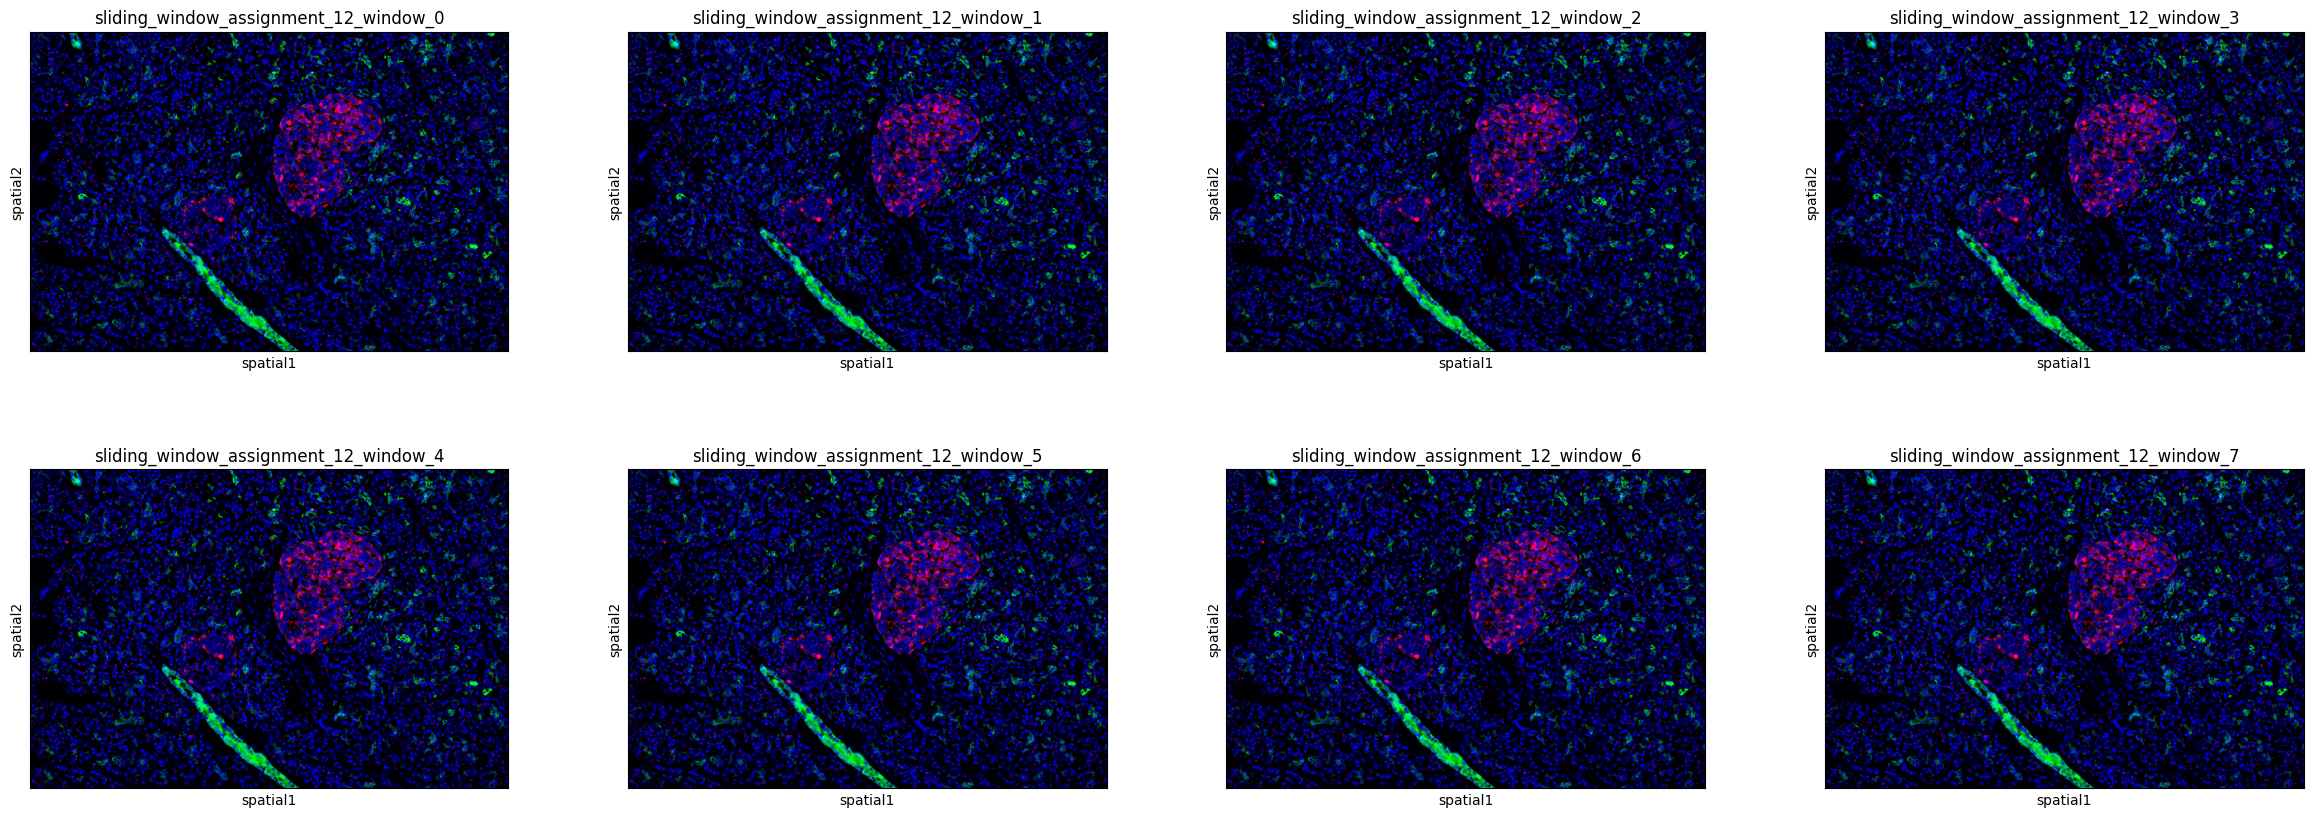

In [37]:
# convert True/False to category so we can vizualize it
adata_s1_12.obs[cols] = adata_s1_12.obs[cols].astype("category")

sq.pl.spatial_scatter(
    adata_s1_12,
    color=cols,
    library_key="fov",
    library_id="12",
    legend_loc=None,
)
plt.tight_layout()

In [16]:
sliding_window_id = 'sliding_window_assignment'

In [17]:
cells_per_window = adata_s1.obs.groupby(sliding_window_id).size()
print(f'Cells per window stats: Max: {cells_per_window.max()}, MIN: {cells_per_window.min()}, mean: {cells_per_window.mean()}, nr. of windows: {len(cells_per_window)}')

Cells per window stats: Max: 1436, MIN: 5, mean: 759.536231884058, nr. of windows: 138


/tmp/ipykernel_1286517/418558507.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cells_per_window = adata_s1.obs.groupby(sliding_window_id).size()


In [6]:
adata.obs['x'] = adata.obs['CenterX_global_px']
adata.obs['y'] = adata.obs['CenterY_global_px']

NameError: name 'adata' is not defined

In [6]:
for ID in ['sliding_window_1', 'sliding_window_2', 'sliding_window_3', 'sliding_window_4']:
    del adata.obs[ID] 

In [8]:
sliding_window(adata, library_key = 'slide_fov', window_size=2100, overlap=1200)
#sliding_window(adata, library_key = 'slide_fov', window_size=2100, overlap=0)
#sliding_window(adata, library_key = 'slide_fov', window_size=1450, overlap=1000)

In [16]:
# cells_per_window = adata.obs.groupby('sliding_window').size()
# print(f'Cells per window stats: Max: {cells_per_window.max()}, MIN: {cells_per_window.min()}, mean: {cells_per_window.mean()}, nr. of windows: {len(cells_per_window)}')

In [24]:
del adata.uns['sliding_window_2_colors']

In [9]:
for sliding_window_id in ['sliding_window_1', 'sliding_window_2', 'sliding_window_3', 'sliding_window_4']:
    cells_per_window = adata.obs.groupby(sliding_window_id).size()
    print(f'Cells per window stats: Max: {cells_per_window.max()}, MIN: {cells_per_window.min()}, mean: {cells_per_window.mean()}, nr. of windows: {len(cells_per_window)}')

KeyError: 'sliding_window_1'

In [40]:
adata_s1_fov_12 = adata[adata.obs['slide_fov'] == '1_12']

In [50]:
del adata_s1_fov_12.uns['sliding_window_4_colors']

/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:981: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:981: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:981: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(
/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:981: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' wi

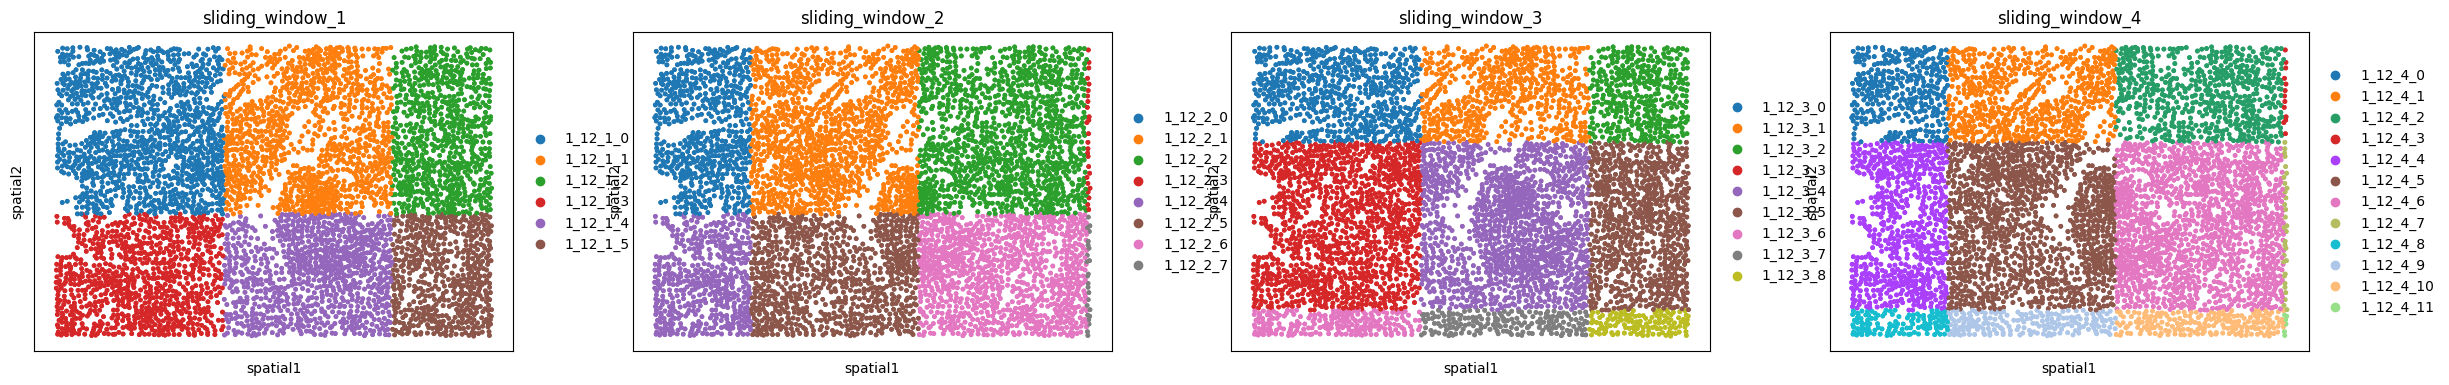

In [51]:
sq.pl.spatial_scatter(
            adata_s1_fov_12,
            color = ['sliding_window_1', 'sliding_window_2', 'sliding_window_3', 'sliding_window_4'],
            spatial_key = 'spatial',
            shape= None,
)

/home/icb/francesca.drummer/tools/apps/mamba/envs/exphormer_mamba/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:483: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = color_source_vector.map(color_map)
/home/icb/francesca.drummer/tools/apps/mamba/envs/exphormer_mamba/lib/python3.11/site-packages/squidpy/pl/_spatial_utils.py:956: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = scatter(


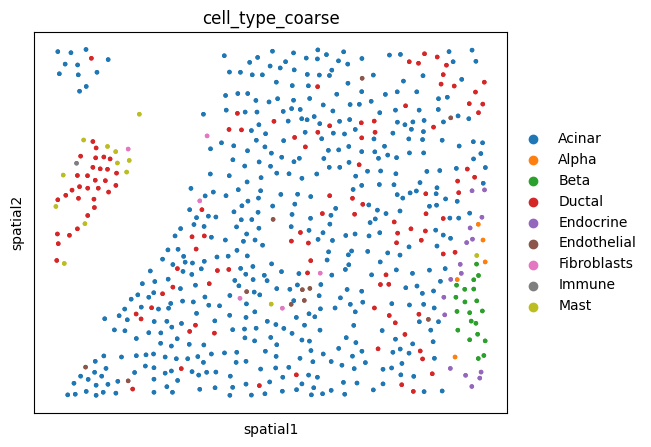

In [16]:
sq.pl.spatial_scatter(
    adata,
    spatial_key = 'spatial',
    shape=None,
    library_key='sliding_window', 
    library_id = ['1_0_1'], 
    color="cell_type_coarse", #cell_type_coarse",
    #groups=['immune', 'stroma'],
    size = 20,
    #edges_width=10.0, edges_color='red'
)

In [52]:
adata.write(COSMX_PANCREAS)

**Make obs_name in a int/float convertable**

In [25]:
adata

AnnData object with n_obs × n_vars = 386727 × 979
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.MembraneStain', 'Max.MembraneStain', 'Mean.PanCK', 'Max.PanCK', 'Mean.GCG', 'Max.GCG', 'Mean.CD3', 'Max.CD3', 'Mean.DAPI', 'Max.DAPI', 'cell_ID', 'condition', 'slide', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_NegPrb', 'log1p_total_counts_NegPrb', 'pct_counts_NegPrb', 'n_genes', 'cell_type_coarse', 'CellTypes_max', 'donor', 'cell_type', 'leiden_covet_0.1', 'Niche_label', 'slide_fov', 'x', 'y', 'globalX', 'globalY', 'sliding_window'
    uns: 'CellTypes_max_colors', 'dendrogram_Niche_label', 'design_matrix', 'hvg', 'leiden_covet_0.1', 'n_neighbors=30', 'neighbors', 'pca', 'spatial', 'umap'
    obsm: 'X_pca', 'X_umap', 'covet-n_neighbors=30', 'covet_sqrt-n_n

In [22]:
str_list = [str(i) for i in list(range(0, len(adata.obs_names)))]

In [23]:
adata.obs_names = str_list

In [26]:
adata.obs_names

Index(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9',
       ...
       '386717', '386718', '386719', '386720', '386721', '386722', '386723',
       '386724', '386725', '386726'],
      dtype='object', length=386727)

### Neighborhood connectivity

In [ ]:
sq.gr.spatial_neighbors(
    adata,
    radius=150,
    coord_type=spatial_neigbors_kwargs.coord_type,
    library_key = spatial_neigbors_kwargs.library_key
)

In [ ]:
# Print average number of connections per node
avg_connections = conn.nnz / conn.shape[0]  # total connections / number of nodes
print(f"Average number of connections per node: {avg_connections:.2f}")

## Sliding window selection

Statistics for sliding_window_1:
count     426.000000
mean      907.809859
std       339.352378
min         5.000000
25%       664.750000
50%       882.000000
75%      1144.500000
max      1926.000000
dtype: float64


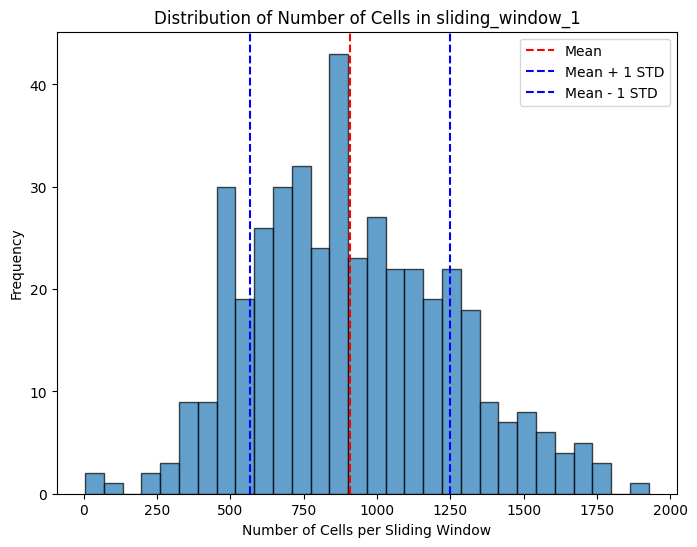

Statistics for sliding_window_2:
count     568.000000
mean      680.857394
std       478.089122
min         1.000000
25%        41.500000
50%       725.500000
75%      1041.250000
max      1852.000000
dtype: float64


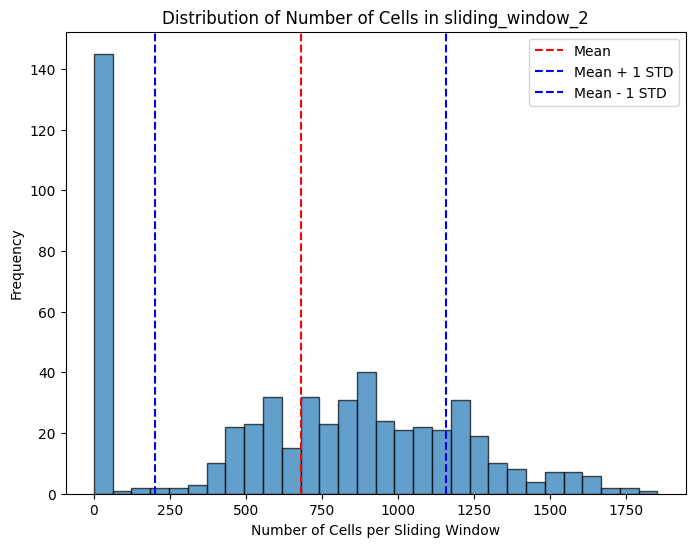

Statistics for sliding_window_3:
count     637.000000
mean      607.106750
std       433.964213
min        14.000000
25%       189.000000
50%       582.000000
75%       869.000000
max      1988.000000
dtype: float64


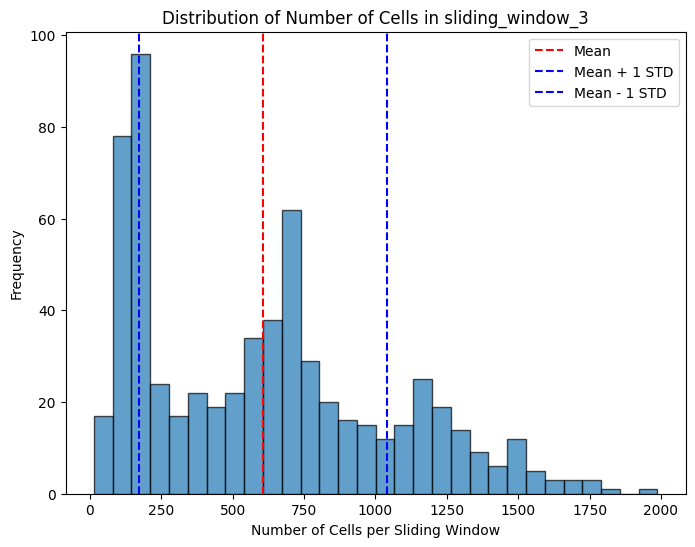

Statistics for sliding_window_4:
count     846.000000
mean      457.124113
std       450.351531
min         2.000000
25%        38.500000
50%       263.000000
75%       742.500000
max      1981.000000
dtype: float64


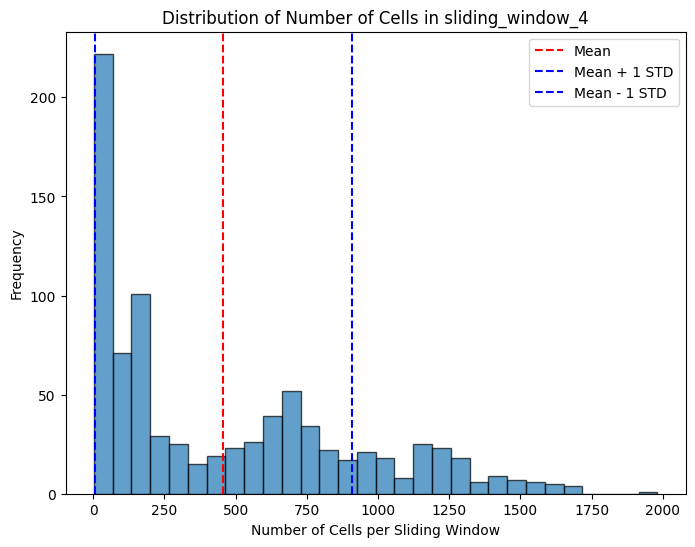

In [18]:
total_window_counts = 0

# Iterate through each sliding window ID column
for sliding_window_id in adata.obs.columns[adata.obs.columns.str.contains("sliding_window")]:
    # Calculate the size (number of cells) for each sliding window
    window_sizes = adata.obs.groupby(sliding_window_id).size()
    
    # Display the window sizes
    print(f"Statistics for {sliding_window_id}:")
    print(window_sizes.describe())  # Get a summary of the statistics (min, max, mean, etc.)
    
    # Calculate and print additional statistics
    max_cells = window_sizes.max()
    min_cells = window_sizes.min()
    mean_cells = window_sizes.mean()
    std_cells = window_sizes.std()

    if mean_cells > 2000:
        print(f'Delete {sliding_window_id}')
        del adata.obs[sliding_window_id]
    else:
        total_window_counts += len(window_sizes)
        
        # Plot the distribution of the number of cells
        plt.figure(figsize=(8, 6))
        plt.hist(window_sizes, bins=30, alpha=0.7, edgecolor='black')
        plt.axvline(mean_cells, color='red', linestyle='--', label='Mean')
        plt.axvline(mean_cells + std_cells, color='blue', linestyle='--', label='Mean + 1 STD')
        plt.axvline(mean_cells - std_cells, color='blue', linestyle='--', label='Mean - 1 STD')
        plt.xlabel('Number of Cells per Sliding Window')
        plt.ylabel('Frequency')
        plt.title(f'Distribution of Number of Cells in {sliding_window_id}')
        plt.legend()
        plt.show()